#### **🔺 챔피언들의 기본 스탯 정보 분포 확인하기**
- 챔피언의 체력, 방어력, 공격력 정보 분포 확인 후, 기준값 선정 예정
    - 분포가 치우쳐 있다면 중앙값을 기준으로 사용하고, 치우쳐 있지 않다면 평균값을 기준으로 편차를 계산할 예정
- `df_champion_eng` : 컬럼명이 영어로 된 데이터 프레임
- `df_champion_kor` : 컬럼명이 한글로 된 데이터 프레임

In [21]:
# 라이브러리 로드
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 한글 설정 및 마이너스 기호 깨짐 설정

os_name = platform.system() # 운영체제 확인

if os_name == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin': 
    plt.rcParams['font.family'] = 'AppleGothic' # Mac
else: 
    plt.rcParams['font.family'] = 'NanumGothic' # Linux/Colab

plt.rcParams['axes.unicode_minus'] = False

In [22]:
# 데이터 로드
df_champion_eng = pd.read_csv("../../tft_game_dataset/TFT_Champion_CurrentVersion.csv")

In [23]:
# 데이터프레임 확인
display(df_champion_eng.head(1))
print('='*60)
print(df_champion_eng.info())

,name,cost,health,defense,attack,attack_range,speed_of_attack,dps,skill_name,skill_cost,origin,class
0,gangplank,5,1000,30,60,1,1.0,60,gangplank_orbitalstrike,100/175,Space Pirate,"['Mercenary', 'Demolitionist']"


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             52 non-null     str    
 1   cost             52 non-null     int64  
 2   health           52 non-null     int64  
 3   defense          52 non-null     int64  
 4   attack           52 non-null     int64  
 5   attack_range     52 non-null     int64  
 6   speed_of_attack  52 non-null     float64
 7   dps              52 non-null     int64  
 8   skill_name       52 non-null     str    
 9   skill_cost       52 non-null     str    
 10  origin           52 non-null     str    
 11  class            52 non-null     str    
dtypes: float64(1), int64(6), str(5)
memory usage: 5.0 KB
None


In [24]:
# 영문명으로 작성된 컬럼명을 한국어로 변환
champion_info_mapping = {
    "name": "챔피언이름",
    "cost": "코스트",
    "health": "체력",
    "defense": "방어력",
    "attack": "공격력",
    "attack_range": "공격 사거리",
    "speed_of_attack": "공격 속도",
    "dps": "DPS",
    "skill_name": "스킬명",
    "skill_cost": "스킬 코스트",
    "origin": "시너지(계열)",
    "class": "시너지(직업)"
}

df_champion_kor = df_champion_eng.rename(columns=champion_info_mapping)

# 데이터프레임 확인
display(df_champion_kor.head(1))
print('='*60)
print(df_champion_kor.info())

,챔피언이름,코스트,체력,방어력,공격력,공격 사거리,공격 속도,DPS,스킬명,스킬 코스트,시너지(계열),시너지(직업)
0,gangplank,5,1000,30,60,1,1.0,60,gangplank_orbitalstrike,100/175,Space Pirate,"['Mercenary', 'Demolitionist']"


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   챔피언이름    52 non-null     str    
 1   코스트      52 non-null     int64  
 2   체력       52 non-null     int64  
 3   방어력      52 non-null     int64  
 4   공격력      52 non-null     int64  
 5   공격 사거리   52 non-null     int64  
 6   공격 속도    52 non-null     float64
 7   DPS      52 non-null     int64  
 8   스킬명      52 non-null     str    
 9   스킬 코스트   52 non-null     str    
 10  시너지(계열)  52 non-null     str    
 11  시너지(직업)  52 non-null     str    
dtypes: float64(1), int64(6), str(5)
memory usage: 5.0 KB
None


In [25]:
# 분석에서 제외할 컬럼 정의
drop_cols = ['스킬명', '스킬 코스트', '시너지(계열)', '시너지(직업)']

# 사용하지 않는 컬럼 제외
df_champion_kor_clean = df_champion_kor.drop(columns=drop_cols, errors='ignore')

# 결과 확인
display(df_champion_kor_clean.head(1))

,챔피언이름,코스트,체력,방어력,공격력,공격 사거리,공격 속도,DPS
0,gangplank,5,1000,30,60,1,1.0,60


In [27]:
# 기초 통계량 확인
df_champion_kor_clean.describe()

,코스트,체력,방어력,공격력,공격 사거리,공격 속도,DPS
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,2.750000,681.730769,28.269231,52.980769,2.153846,0.730769,39.019231
std,1.355815,145.531092,7.533235,11.684564,1.348705,0.118881,11.884230
min,1.000000,450.000000,20.000000,10.000000,1.000000,0.500000,8.000000
25%,2.000000,600.000000,20.000000,45.000000,1.000000,0.650000,32.000000
50%,3.000000,650.000000,30.000000,50.000000,1.500000,0.700000,35.500000
75%,4.000000,762.500000,35.000000,60.000000,3.000000,0.800000,44.250000
max,5.000000,1100.000000,40.000000,90.000000,5.000000,1.000000,81.000000


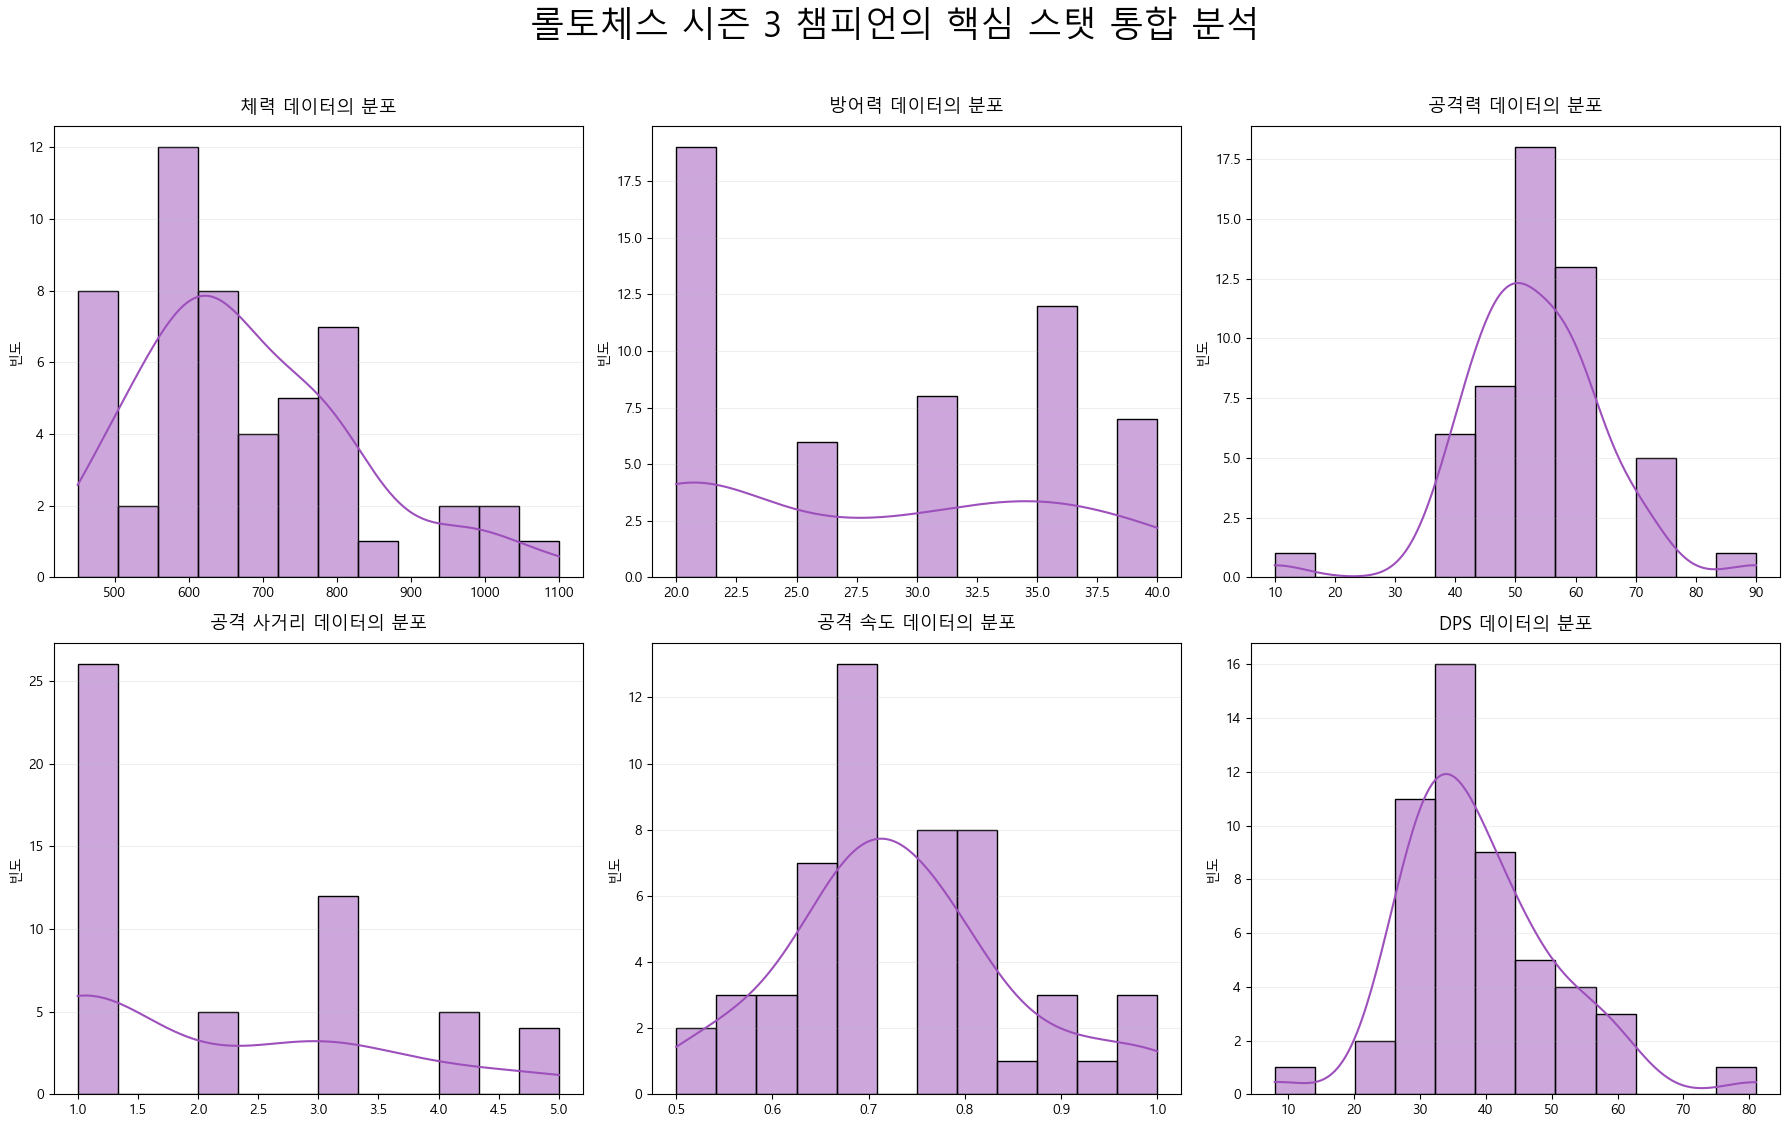


[시즌 3 갤럭시] 챔피언의 주요 스탯 수치 요약 (1성 기준)


,스탯 항목,왜도(Skewness),첨도(Kurtosis),평균(Mean),중앙값(Median)
0,체력,0.849444,0.524280,681.730769,650.0
1,방어력,0.193058,-1.494712,28.269231,30.0
2,공격력,-0.217528,3.850644,52.980769,50.0
3,공격 사거리,0.756355,-0.699754,2.153846,1.5
4,공격 속도,0.424233,0.236498,0.730769,0.7
5,DPS,0.875761,2.401160,39.019231,35.5


In [38]:
# 컬럼 선정
target_cols = ['체력', '방어력', '공격력', '공격 사거리', '공격 속도', 'DPS']

# 시각화 (2x3 레이아웃)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    skew_val = df_champion_kor_clean[col].skew()
    kurt_val = df_champion_kor_clean[col].kurt()
    
    # 히스토그램 + KDE
    sns.histplot(df_champion_kor_clean[col], kde=True, color='#9D50BB', ax=axes[i], bins=12)
    
    # 세부 설정
    axes[i].set_title(f"{col} 데이터의 분포", fontsize=13, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', alpha=0.2)

plt.suptitle("롤토체스 시즌 3 챔피언의 핵심 스탯 통합 분석", fontsize=25, y=1.02)
plt.tight_layout()
plt.show()

# 통계 요약표 생성 (DataFrame 활용)
summary_list = []
for col in target_cols:
    summary_list.append({
        '스탯 항목': col,
        '왜도(Skewness)': df_champion_kor_clean[col].skew(),
        '첨도(Kurtosis)': df_champion_kor_clean[col].kurt(),
        '평균(Mean)': df_champion_kor_clean[col].mean(),
        '중앙값(Median)': df_champion_kor_clean[col].median()
    })

df_summary = pd.DataFrame(summary_list)

# 결과 출력
print(f"\n{'='*60}")
print(f"[시즌 3 갤럭시] 챔피언의 주요 스탯 수치 요약 (1성 기준)")
print(f"{'='*60}")
display(df_summary)

In [39]:
# 중앙값을 사용하여 편차 계산
# 이유: 특정 유닛 중 극단적인 수치를 가진 데이터에 대비하기 위해서
for col in target_cols:
    median_val = df_champion_kor_clean[col].median()
    # 중앙값 대비 편차 (%)
    df_champion_kor_clean[f'{col}_편차'] = (df_champion_kor_clean[col] - median_val) / median_val * 100

In [41]:
# 결과 확인
df_champion_kor_clean.head(10)

,챔피언이름,코스트,체력,방어력,공격력,공격 사거리,공격 속도,DPS,체력_편차,방어력_편차,공격력_편차,공격 사거리_편차,공격 속도_편차,DPS_편차
0,gangplank,5,1000,30,60,1,1.00,60,53.846154,0.000000,20.0,-33.333333,42.857143,69.014085
1,graves,1,650,35,55,1,0.55,30,0.000000,16.666667,10.0,-33.333333,-21.428571,-15.492958
2,neeko,3,800,35,50,2,0.65,33,23.076923,16.666667,0.0,33.333333,-7.142857,-7.042254
3,darius,2,750,35,60,1,0.65,39,15.384615,16.666667,20.0,-33.333333,-7.142857,9.859155
4,rakan,2,600,35,45,2,0.70,32,-7.692308,16.666667,-10.0,33.333333,0.000000,-9.859155
5,lux,3,600,20,40,4,0.70,28,-7.692308,-33.333333,-20.0,166.666667,0.000000,-21.126761
6,rumble,3,800,35,50,1,0.70,35,23.076923,16.666667,0.0,-33.333333,0.000000,-1.408451
7,leona,1,600,40,50,1,0.55,28,-7.692308,33.333333,0.0,-33.333333,-21.428571,-21.126761
8,lucian,2,500,25,50,4,0.70,35,-23.076923,-16.666667,0.0,166.666667,0.000000,-1.408451
9,lulu,5,800,25,45,3,0.80,36,23.076923,-16.666667,-10.0,100.000000,14.285714,1.408451


In [42]:
# csv 파일로 저장하기
df_champion_kor_clean.to_csv("./챔피언의기본스탯정보-편차.csv")